# Analyze and plot the results of T-maze simulation

### Import

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [2]:
scenario = "Tmaze"
trial_number = 10
use_example = True
save_plot = False

In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
data_path = os.path.join(base_path,"data",scenario)
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "example" if use_example else "trial"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

# Add the directory to sys.path
ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

from global_variables import *
from Tmaze_variables import *
from Tmaze_functions import *
from plots import *

# Fig. 4, Online learning

### Fig 4c, Plot averaged weights

In [4]:
load_lap = 10

CA3_weights = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))
CA1_weights = np.zeros((num_CA1_neurons,num_CA3_neurons,len(target_seed)))

CA3_place_fields = load_PF_starts()

for ii,seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))
    CA3_weights[:,:,ii] = ff["w_CA3_CA3"]; CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%(load_lap)))
    place_field_sorted_idx = np.array(list(CA1_place_fields.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights[:,:,ii] = CA1_temp[:,place_cue_mix_idx]


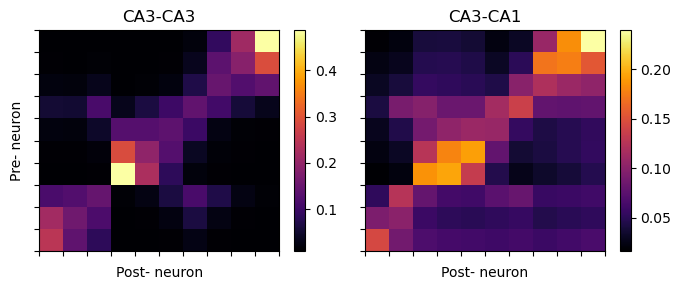

In [5]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
CA1_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_wmx_arr[:,:,seed] = average_weight(CA3_weights[:,:,seed], n_pops, n_pops)
    CA1_mean_wmx_arr[:,:,seed] = average_weight(CA1_weights[:,:,seed], n_pops, n_pops)

CA3_mean_wmx = CA3_mean_wmx_arr.mean(-1)
CA1_mean_wmx = CA1_mean_wmx_arr.mean(-1)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA3_mean_wmx, fig=fig, ax=axs[0], title="CA3-CA3")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA1_mean_wmx, fig=fig, ax=axs[1], title="CA3-CA1")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"avg_hippocampal_weights_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 4d, Predicted presence of two distinct rewards at each state

In [38]:
target_lap = [2,4,6,7,8,9,10]
foldername = folder_root + str(target_seed[0])
unit_gran = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_2.npz"))["unit_gran"]

W_feat_arr = np.zeros((len(target_seed),len(target_lap),num_CA1_neurons,num_features))
feat_pred_state = np.zeros((len(target_seed),len(target_lap),num_state_total,num_features))

for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    for ee, load_lap in enumerate(target_lap):
        w_CA1_feat=np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
        CA1_activity = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_%d.npz"%load_lap))["CA1_activity"]
        CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%load_lap))

        place_field_sorted_idx = np.array(list(CA1_PF.keys()))
        place_cue_div_idx = np.hstack((place_field_sorted_idx,np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)))
        place_cue_mix_idx = np.zeros(num_CA1_neurons)
        pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
        place_cue_mix_idx[pp_idx] = place_field_sorted_idx
        cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
        place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
        place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
        
        W_feat_arr[mm,ee,:,:] = w_CA1_feat[place_cue_mix_idx,:]
        feat_pred_arr = CA1_activity@w_CA1_feat

        for ss in range(num_state_total):
            feat_pred_state[mm,ee,ss] = np.max(np.squeeze(feat_pred_arr[ss*unit_gran+1:(ss+1)*unit_gran-1]),axis=0)

In [39]:
def plot_Tmaze_heat(data,ax,colormap='RdBu_r',vmax=1.5):
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    Tmaze_grid = np.array([state_position[ss]-[0.5,0.5] for ss in range(num_state_total)],dtype=int)
    data_arr = np.zeros((num_state_row+1,num_state_col))
    for ss in range(num_state_total):
        data_arr[Tmaze_grid[ss,0],Tmaze_grid[ss,1]] = data[ss]
    im = ax.imshow(data_arr, cmap=colormap, norm=norm)  # shading='auto' avoids shape mismatch

    for ss in range(num_state_total):
        x_mid = Tmaze_grid[ss,1]; y_mid = Tmaze_grid[ss,0]
        ax.hlines(y=[y_mid-0.5, y_mid+0.5], xmin=x_mid-0.5, xmax=x_mid+0.5, color='k', linewidth=1.5)
        ax.vlines(x=[x_mid-0.5, x_mid+0.5], ymin=y_mid-0.5, ymax=y_mid+0.5, color='k', linewidth=1.5)

    ax.set_xticks([]); ax.set_yticks([])
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(False)

    return im

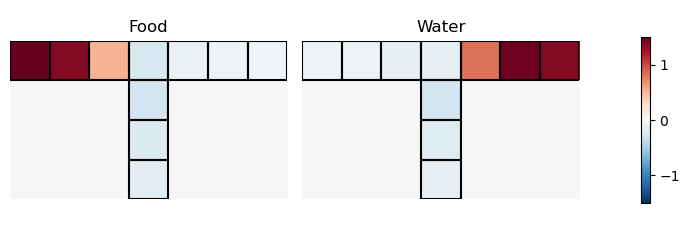

In [ ]:
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.5)

RW_pred_state = np.zeros((len(target_seed),num_state_total,2))
RW_pred_state[:,:,0] = np.squeeze(feat_pred_state[:,-2,:,0]); RW_pred_state[:,:,1] = np.squeeze(feat_pred_state[:,-1,:,1])

fig,axs = plt.subplots(1,3,width_ratios=[5,5,1],figsize=(7, 2.5))
plot_Tmaze_heat(RW_pred_state.mean(0)[:,0],axs[0]); axs[0].set_title("Food")
im = plot_Tmaze_heat(RW_pred_state.mean(0)[:,1],axs[1]); axs[1].set_title("Water")

axs[2].set_xticks([]); axs[2].set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    axs[2].spines[spine].set_visible(False)

fig.colorbar(im, ax=axs[2])

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Reward_unit_activity.png"), dpi=300)
plt.show()

### Fig. 4g, Markov transition matrices based on motivational state

In [41]:
num_behav_trial = 500
total_time = 50
possible_actions = np.array([[0,0],[0,-1],[0,1],[-1,0],[1,0]])  # left, stay, right
max_MI = 10; num_MI_scenario = max_MI+2
value_vector = np.ones((num_MI_scenario,2))

for MI in range(max_MI-1):
    value_vector[MI+1,0] = MI+2
value_vector[max_MI,1] = max_MI/2
value_vector[-1,0] = max_MI/2; value_vector[-1,1] = 0

value_arr = np.zeros((len(target_seed),num_MI_scenario,num_state_total))
for ii in range(len(target_seed)):
    for vv in range(num_MI_scenario):
        norm_pred = pred_norm(RW_pred_state[ii,:,:])
        value_arr[ii,vv,:] = norm_pred@value_vector[vv,:]
transition_matrix = np.zeros((len(target_seed), num_MI_scenario, num_state_total, num_state_total))

for mm in range(len(target_seed)):
    for vv in range(num_MI_scenario):
        transition_matrix[mm,vv,:,:], _ = compute_transition_matrix(num_state_total,value_arr[mm,vv],possible_actions,end_state=[3,9],softmax_coeff=0.5)

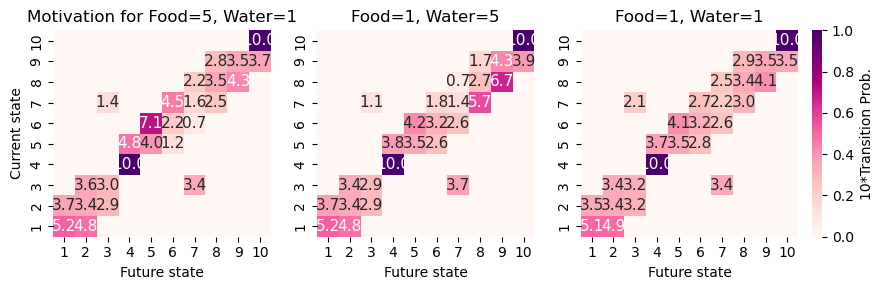

In [42]:
fig, axs = plt.subplots(1,3,width_ratios=(4,4,5),figsize=(9,3))
annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[4])
sns.heatmap(transition_matrix.mean(0)[4], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[0],cbar=False)
axs[0].set_xticklabels(np.arange(1,num_state_total+1)); axs[0].set_yticklabels(np.arange(1,num_state_total+1))
axs[0].invert_yaxis(); axs[0].set_ylabel("Current state"); axs[0].set_xlabel("Future state")
axs[0].set_title("Motivation for Food=5, Water=1")

annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[-2])
sns.heatmap(transition_matrix.mean(0)[-2], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[1],cbar=False)
axs[1].set_xticklabels(np.arange(1,num_state_total+1)); axs[1].set_yticklabels(np.arange(1,num_state_total+1))
axs[1].invert_yaxis(); axs[1].set_xlabel("Future state")
axs[1].set_title("Food=1, Water=5")

annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[0])
sns.heatmap(transition_matrix.mean(0)[0], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[2], cbar_kws={'label': '10*Transition Prob.'})
axs[2].set_xticklabels(np.arange(1,num_state_total+1)); axs[2].set_yticklabels(np.arange(1,num_state_total+1))
axs[2].invert_yaxis(); axs[2].set_xlabel("Future state")
axs[2].set_title("Food=1, Water=1")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Transition_matrix.png"), dpi=300)
plt.show()

### Fig. 4i, Final destination based on different motivational state

In [43]:
trajectory_arr = np.zeros((num_MI_scenario,len(target_seed),num_behav_trial,total_time))
goal_time_arr = np.zeros((num_MI_scenario,len(target_seed),num_behav_trial))
goal_state_arr = np.zeros(goal_time_arr.shape)
goal_count = np.zeros((num_MI_scenario,3,len(target_seed)))

for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        for vv in range(num_MI_scenario):
            trajectory_arr[vv,mm,tt,:],goal_time_arr[vv,mm,tt],goal_state_arr[vv,mm,tt] = behavior_markov(transition_matrix[mm,vv,:,:], total_time=total_time, start_state=0, end_state=[3,9])
            
            if goal_state_arr[vv,mm,tt] == 3: goal_count[vv,0,mm] += 1; continue
            elif goal_state_arr[vv,mm,tt] == 9: goal_count[vv,1,mm] += 1; continue
            else: goal_count[vv,2,mm] += 1

xx = np.arange(num_MI_scenario-2)
goalTime_mean = np.zeros(num_MI_scenario-2); goalTime_std = np.zeros(num_MI_scenario-2)
for vv in range(num_MI_scenario-2):
    goal_time_data = goal_time_arr[vv,:,:].reshape(-1)

    valid_idx = np.where(~np.isnan(goal_time_data))[0]
    goal_time_data = goal_time_data[valid_idx]
    goalTime_mean[vv] = goal_time_data.mean()
    goalTime_std[vv] = goal_time_data.std()/np.sqrt(num_behav_trial)


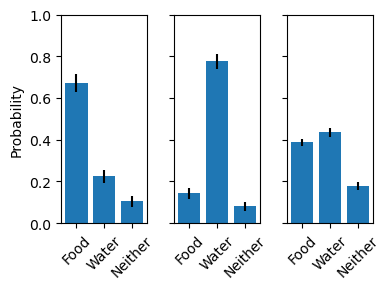

indv. t-test, food vs. water for case 1: 4.43854120295724e-09
indv. t-test, food vs. water for case 2: 1.220603330176147e-10
indv. t-test, food vs. water for case 3: 0.0033409920122716105


In [44]:
fig,axs = plt.subplots(1,3,figsize=(4,3))

for ii,vv in enumerate([4,-2,0]):
    axs[ii].bar(np.arange(3),goal_count[vv].mean(-1)/num_behav_trial,yerr=goal_count[vv].std(-1)/(num_behav_trial)); axs[ii].set_ylim([0,1])
    axs[ii].set_xticks(np.arange(3)); axs[ii].set_xticklabels(["Food","Water","Neither"]); axs[ii].tick_params(axis='x', labelrotation=45)
    if ii>0: axs[ii].set_yticklabels([])
axs[0].set_ylabel("Probability")

fig.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"final_destination.png"), dpi=300)
plt.show()

_,p_val = stats.ttest_rel(goal_count[-3,0],goal_count[-3,1])
print("indv. t-test, food vs. water for case 1:",p_val)

_,p_val = stats.ttest_rel(goal_count[-2,0],goal_count[-2,1])
print("indv. t-test, food vs. water for case 2:",p_val)

_,p_val = stats.ttest_rel(goal_count[0,0],goal_count[0,1])
print("indv. t-test, food vs. water for case 3:",p_val)

### Fig. 4j, time taken to find food reward based on the motivational state

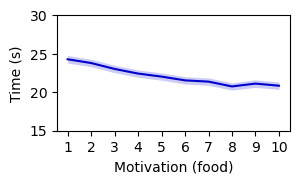

Mann_Kendall_Test(trend='decreasing', h=True, p=0.00034661935113455833, z=-3.5777087639996634, Tau=-0.9111111111111111, s=-41.0, var_s=125.0, slope=-0.41210119501800424, intercept=23.639126553983324)

In [69]:
fig, ax = plt.subplots(1,1,figsize=(3,1.5))
ax = plot_shaded(xx+1,goalTime_mean,goalTime_std,ax,color=[0,0,0.8])
ax.set_xticks(xx+1); ax.set_ylim([15,total_time-20])
ax.set_xlabel("Motivation (food)"); ax.set_ylabel("Time (s)")

if save_plot: plt.savefig(os.path.join(plot_path,"Goal_reach_time.png"), dpi=300)
plt.show()

import pymannkendall as mk
result = mk.original_test(goalTime_mean)
result

# Fig. 5, The impact offline learning based on replay type

### Fig 5b, Spontaneously generated on-site offline activity

In [45]:
import pickle

load_lap = 10; pause_state = 4
replay_time = []

for trial in range(trial_number):
    foldername = folder_root+str(trial)
    trial_list = []
    for replay_type in range(len(replay_trajectory)):
        type_list = []
        fname = os.path.join(data_path,foldername,'replay_type_%d.pkl'%replay_type)
        with open(fname, 'rb') as fp: replays = pickle.load(fp)
        for tt in replays.keys(): type_list.append(list(tt))
        trial_list.append(type_list)
    replay_time.append(trial_list)

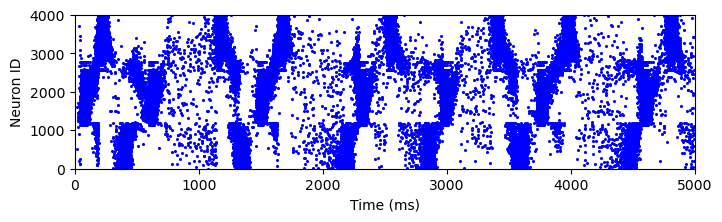

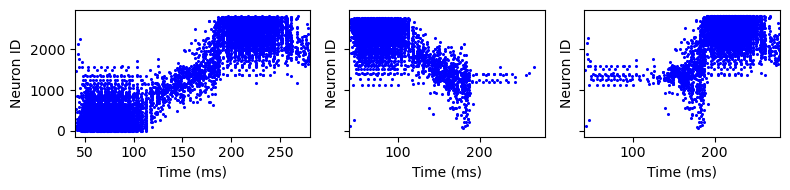

In [46]:
example_trial_idx = 0; 

CA3_PF = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_PF.keys()),dtype=int), np.array(list(CA3_PF.values())))
ff = np.load(os.path.join(data_path,folder_root+str(target_seed[example_trial_idx]),"CA3_replay_lap_%d_pause_%d.npz"%(load_lap, pause_state)))
spike_times_CA3 = ff['spike_times_CA3_PC']; spiking_neurons_CA3 = ff['spiking_neurons_CA3_PC']; rate_CA3 = ff['rate_CA3_PC']
del ff

fig,ax = plt.subplots(1,1,figsize=(8,2))

target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,np.arange(num_state_total))
plot_spike(spike_times_CA3, spiking_neurons_CA3, target_idx,
               zoom_from=0, zoom_to=rest_time, ax=ax)
ax.set_ylim([0, num_CA3_neurons])

fig,axs = plt.subplots(1,3,figsize=(8,2), width_ratios=[1.2,1,1], sharey=True)

for rep_type, rep_traj in enumerate(replay_trajectory):
    time_window = replay_time[example_trial_idx][rep_type][0]
    target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,rep_traj)
    plot_spike(spike_times_CA3, spiking_neurons_CA3, target_idx,
                zoom_from=time_window[0], zoom_to=time_window[1], ax=axs[rep_type])
    # axs[rep_type].set_ylim([0, len(target_idx)]); axs[rep_type].set_ylabel("")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Onsite_replay_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 5d, Food prediction updated induced by different types of replay events

In [56]:
RW_pred_before = list(); RW_pred_after = list()
    
for rep_type in range(len(replay_trajectory)):
    for mm, trial in enumerate(range(trial_number)):
        foldername = folder_root + str(trial)
        replays_trial = replay_time[trial][rep_type]
        w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
        
        before = np.zeros((len(replays_trial),num_state_total)); after = np.zeros_like(before)

        for rr, replay in enumerate(replays_trial):
            bf_time = replay[0]; af_time = replay[1]
            # af_time -= 1 if af_time == 5000 else 0
            if (af_time - bf_time)<200: continue
            bf_act = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d_replay_%d.npz"%(load_lap,bf_time)))["CA1_activity"]
            af_act = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d_replay_%d.npz"%(load_lap,af_time)))["CA1_activity"]

            bf_temp = (bf_act@w_CA1_feat).T[0]; af_temp = (af_act@w_CA1_feat).T[0]

            for ss in range(num_state_total):
                before[rr,ss] = bf_temp[ss*unit_gran:(ss+1)*unit_gran].mean()
                after[rr,ss] = af_temp[ss*unit_gran:(ss+1)*unit_gran].mean()

        if mm == 0: before_type = before; after_type = after
        else: before_type = np.vstack((before_type, before)); after_type = np.vstack((after_type, after))
        del before, after

    RW_pred_before.append(before_type); RW_pred_after.append(after_type)
    del before_type, after_type

/tmp/ipykernel_613958/3879061394.py:15: UserWarning: Adding colorbar to a different Figure <Figure size 700x250 with 4 Axes> than <Figure size 700x150 with 5 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=axs[3])


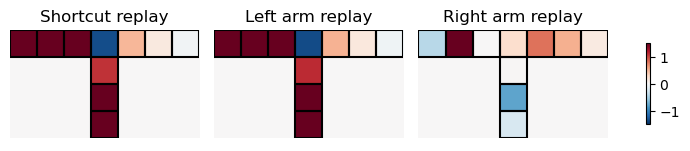

In [70]:
fig, axs = plt.subplots(1,4,width_ratios=[7,7,7,1],figsize=(7, 1.5))

for rr in range(len(replay_trajectory)):
    data = RW_pred_after[rr] - RW_pred_before[rr]
    plot_Tmaze_heat(data.mean(0),axs[rr],vmax=1e-3)

axs[0].set_title("Shortcut replay")
axs[1].set_title("Left arm replay")
axs[2].set_title("Right arm replay")

axs[3].set_xticks([]); axs[3].set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    axs[3].spines[spine].set_visible(False)

fig.colorbar(im, ax=axs[3])

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Prediction_update_replay_types.png"), dpi=300)
plt.show()

### Fig. 5e, Food prediction updated induced by the entire offline activity

In [ ]:
target_seed = np.arange(10)

RW_pred_state_replay = np.zeros((len(target_seed),num_state_total))

for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)

    w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
    activity_replay = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_%d_replay_5000.npz"%load_lap))["CA1_activity"]
    
    RW_pred_arr_replay = activity_replay@w_CA1_feat
    RW_pred_arr_replay = RW_pred_arr_replay[:,0]
    del w_CA1_feat, activity_replay
    
    for ss in range(num_state_total):
        RW_pred_state_replay[mm,ss] = np.max(np.squeeze(RW_pred_arr_replay[ss*unit_gran:(ss+1)*unit_gran]))
    del RW_pred_arr_replay

In [74]:
data.shape

(49, 10)

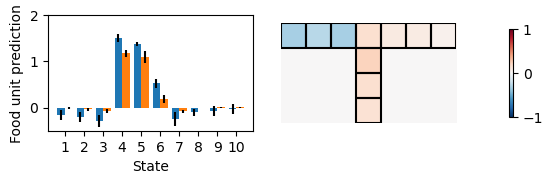

In [87]:
fig,axs = plt.subplots(1,3,width_ratios=[7,6,1],figsize=(6, 1.5))
category = np.arange(num_state_total)+1
bar_width = 0.4
axs[0].bar(category-bar_width/2,RW_pred_state.mean(0)[:,0].T,yerr=RW_pred_state.std(0)[:,0].T, capsize=0, width = bar_width)
axs[0].bar(category+bar_width/2,RW_pred_state_replay.mean(0),yerr=RW_pred_state_replay.std(0), capsize=0, width = bar_width)
axs[0].set_xticks(np.arange(num_state_total)+1); axs[0].set_ylim([-0.5,2])
axs[0].set_xlabel("State"); axs[0].set_ylabel("Food unit prediction")
# plt.show()

# norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
# fig, ax = plt.subplots(1,1,figsize=(7, 1))
# d.T
# c = ax.pcolormesh(np.arange(num_state_total+1)+0.5, np.arange(2),
#                 data.reshape(1,num_state_total),
#                 cmap='RdBu_r', norm=norm)

# fig.colorbar(c, ax=ax)
# plt.yticks([]); plt.xticks(np.arange(num_state_total)+1)
# plt.show()

data = RW_pred_state_replay.mean(0) - RW_pred_state.mean(0)[:,0]
im=plot_Tmaze_heat(data,axs[1],vmax=1)

axs[2].set_xticks([]); axs[2].set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    axs[2].spines[spine].set_visible(False)

fig.colorbar(im, ax=axs[2])

if save_plot: plt.savefig(os.path.join(plot_path,"Prediction_update_entire_offline.png"), dpi=300)
plt.show()

In [48]:
value_food = value_vector[-1,0]

value_arr_replay = np.zeros((len(target_seed),num_state_total))
for ii in range(len(target_seed)):
    norm_pred = pred_norm(RW_pred_state_replay[ii])
    value_arr_replay[ii] = norm_pred*value_food

transition_matrix_replay = np.zeros((len(target_seed), num_state_total, num_state_total))
transition_matrix_newstart = np.zeros((len(target_seed), 2, num_state_total, num_state_total))

for mm in range(len(target_seed)):
    transition_matrix_replay[mm], _ = compute_transition_matrix(num_state_total,value_arr_replay[mm],possible_actions,end_state=[3,9])
    transition_matrix_newstart[mm,0], _ = compute_transition_matrix(num_state_total,value_arr[mm,-1,:],possible_actions,end_state=[0,3])
    transition_matrix_newstart[mm,1], _ = compute_transition_matrix(num_state_total,value_arr_replay[mm],possible_actions,end_state=[0,3])


In [49]:
trajectory_arr_replay = np.zeros((len(target_seed),num_behav_trial,total_time))
goal_time_arr_replay = np.zeros((len(target_seed),num_behav_trial))
goal_state_arr_replay = np.zeros(goal_time_arr_replay.shape)
goal_count_replay = np.zeros((3,len(target_seed)))

trajectory_arr_newstart = np.zeros((2,len(target_seed),num_behav_trial,total_time))
goal_time_arr_newstart = np.zeros((2,len(target_seed),num_behav_trial))
goal_state_arr_newstart = np.zeros(goal_time_arr_newstart.shape)
goal_count_newstart= np.zeros((2,3,len(target_seed)))

for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        trajectory_arr_replay[mm,tt,:],goal_time_arr_replay[mm,tt],goal_state_arr_replay[mm,tt] = behavior_markov(transition_matrix_replay[mm], total_time=total_time, start_state=0, end_state=[3,9])
        if goal_state_arr_replay[mm,tt] == 3: goal_count_replay[0,mm] += 1; continue
        elif goal_state_arr_replay[mm,tt] == 9: goal_count_replay[1,mm] += 1; continue
        else: goal_count_replay[2,mm] += 1

        for vv in range(2):
            trajectory_arr_newstart[vv,mm,tt,:],goal_time_arr_newstart[vv,mm,tt],goal_state_arr_newstart[vv,mm,tt] = behavior_markov(transition_matrix_newstart[mm,vv,:,:], total_time=total_time, start_state=9, end_state=[3,0])
            if goal_state_arr_newstart[vv,mm,tt] == 3: goal_count_newstart[vv,0,mm] += 1; continue
            elif goal_state_arr_newstart[vv,mm,tt] == 0: goal_count_newstart[vv,1,mm] += 1; continue
            else: goal_count_newstart[vv,2,mm] += 1

In [51]:
goalcnt_df = pd.DataFrame(columns=['Replay','Scenario','P(food)'])
for mm in target_seed:
    goalcnt_df.loc[len(goalcnt_df)] = ['Before','Familiar',goal_count[-1,0,mm]/num_behav_trial]

    d = goal_time_arr_replay[mm]; d = d[~np.isnan(d)]
    goalcnt_df.loc[len(goalcnt_df)] = ['After','Familiar',goal_count_replay[0,mm]/num_behav_trial]

    d = np.squeeze(goal_time_arr_newstart[0,mm]); d = d[~np.isnan(d)]
    goalcnt_df.loc[len(goalcnt_df)] = ['Before','Novel',goal_count_newstart[0,0,mm]/num_behav_trial]

    d = np.squeeze(goal_time_arr_newstart[1,mm]); d = d[~np.isnan(d)]
    goalcnt_df.loc[len(goalcnt_df)] = ['After','Novel',goal_count_newstart[1,0,mm]/num_behav_trial]


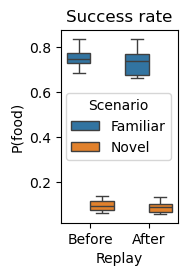

Paired t-test, Familiar, wo offline vs. with offline, p_value: 0.23723149679803557
Paired t-test, Novel, wo offline vs. with offline, p_value: 0.026149794148773345


In [52]:
plt.figure(figsize=(1.5, 2.5))
sns.boxplot(x='Replay', y='P(food)', hue='Scenario', data=goalcnt_df)
plt.title('Success rate')
plt.show()

fam_bf = goalcnt_df[(goalcnt_df['Replay']=='Before')&(goalcnt_df['Scenario']=='Familiar')]['P(food)']
fam_af = goalcnt_df[(goalcnt_df['Replay']=='After')&(goalcnt_df['Scenario']=='Familiar')]['P(food)']
nov_bf = goalcnt_df[(goalcnt_df['Replay']=='Before')&(goalcnt_df['Scenario']=='Novel')]['P(food)']
nov_af = goalcnt_df[(goalcnt_df['Replay']=='After')&(goalcnt_df['Scenario']=='Novel')]['P(food)']

_,p_val = stats.ttest_rel(fam_bf,fam_af)
print("Paired t-test, Familiar, wo offline vs. with offline, p_value:",p_val)
_,p_val = stats.ttest_rel(nov_bf,nov_af)
print("Paired t-test, Novel, wo offline vs. with offline, p_value:",p_val)


In [53]:
goaltime_df = pd.DataFrame(columns=['Replay','Scenario','Time (s)'])
for mm in target_seed:
    d = np.squeeze(goal_time_arr[-1,mm]); d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['Before','Familiar',d.mean()]

    d = goal_time_arr_replay[mm]; d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['After','Familiar',d.mean()]

    d = np.squeeze(goal_time_arr_newstart[0,mm]); d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['Before','Novel',d.mean()]

    d = np.squeeze(goal_time_arr_newstart[1,mm]); d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['After','Novel',d.mean()]


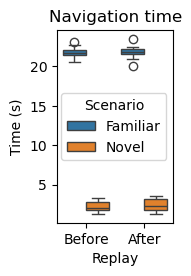

Paired t-test, Familiar, wo offline vs. with offline, p_value: 0.6944376022049519
Paired t-test, Novel, wo offline vs. with offline, p_value: 0.04502953099896601


In [54]:
plt.figure(figsize=(1.5, 2.5))
sns.boxplot(x='Replay', y='Time (s)', hue='Scenario', data=goaltime_df)
plt.title('Navigation time')
plt.show()

fam_bf = goaltime_df[(goaltime_df['Replay']=='Before')&(goaltime_df['Scenario']=='Familiar')]['Time (s)']
fam_af = goaltime_df[(goaltime_df['Replay']=='After')&(goaltime_df['Scenario']=='Familiar')]['Time (s)']
nov_bf = goaltime_df[(goaltime_df['Replay']=='Before')&(goaltime_df['Scenario']=='Novel')]['Time (s)']
nov_af = goaltime_df[(goaltime_df['Replay']=='After')&(goaltime_df['Scenario']=='Novel')]['Time (s)']

_,p_val = stats.ttest_rel(fam_bf,fam_af)
print("Paired t-test, Familiar, wo offline vs. with offline, p_value:",p_val)
_,p_val = stats.ttest_rel(nov_bf,nov_af)
print("Paired t-test, Novel, wo offline vs. with offline, p_value:",p_val)
